# Pipeline 04 — Reintegration Readiness

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: Individual home visitation (1,337 rows)  
**Label**: `label_favorable` = 1 if `visit_outcome == 'Favorable'` (551 / 1,337 = 41.2%)  
**Seed**: 42  

---


## 1. Problem Framing

### Business Question

> *"Which residents are progressing toward favorable reintegration outcomes, and what factors are most associated with success?"*

This notebook includes both a predictive and an explanatory track, but the **primary deployed use is predictive**. In textbook terms, the live business decision is future-facing: staff want to know **which residents should be prioritized for reintegration review next**. The explanatory model is still valuable because program leaders need to understand which observable patterns are associated with favorable outcomes and where those relationships may simply reflect selection effects.

| Goal | Description | Value |
|------|-------------|-------|
| **Predictive** | Rank residents by likelihood of a favorable visit outcome | Supports case-planning: where should supervisors focus attention *before* the next visit? |
| **Explanatory** | Identify which observable factors *associate* with favorable outcomes | Informs program design: what patterns appear alongside successful reintegration readiness? |

### Stakeholders

- **Case supervisors** use predictions to prioritize review and planning.
- **Program directors** use the explanatory output to assess broader intervention strategy.
- **Resident-facing staff** need a model that supports, not overrides, clinical and social-work judgment.


### Business Question

> *"Which residents are progressing toward favorable reintegration outcomes, and what factors are most associated with success?"*

This pipeline is **dual-purpose** — it serves both a predictive and an explanatory goal simultaneously, which is deliberate:

| Goal | Description | Value |
|------|-------------|-------|
| **Predictive** | Rank residents by likelihood of a favorable visit outcome | Supports case-planning: where should supervisors focus attention *before* the next visit? |
| **Explanatory** | Identify which observable factors *associate* with favorable outcomes | Informs program design: what can the organization change to improve outcomes at scale? |

Both goals are valuable because a pure black-box predictor cannot justify resource reallocation, while a pure statistical summary cannot prioritize individual cases.

---

### Stakeholders

- **Case supervisors** — use predictions to prioritize check-ins and flag residents needing support before a scheduled visit
- **Program directors** — use explanatory output to redesign visit protocols, family engagement programs, and staff training

---

### Feasibility Assessment

| Dimension | Assessment |
|-----------|------------|
| Data availability | Confirmed: 1,337 visitation rows, 5 linked tables |
| Label quality | `visit_outcome` is a structured field assigned by a social worker; not self-reported |
| Class balance | 41.2% positive — mildly imbalanced; manageable with `class_weight='balanced'` |
| Temporal structure | Visits span 2023–2027; time-based train/test split is feasible |
| Sample size | 1,337 visits across only 60 residents — visits are correlated within resident; **this is a key limitation** |
| Actionability | Several features (visit frequency, visit type mix, follow-up adherence) are within organizational control |

---

### Ethics Note

This model produces predictions about real girls' reintegration readiness. Several ethical constraints apply:

1. **Advisory only** — model output is a decision-support signal, never an automated gate. Final reintegration decisions remain with licensed social workers and supervising partner agencies.
2. **Partial control** — factors like family cooperation are substantially outside a resident's control. Predictions must never be framed as reflecting the resident's effort or character.
3. **Disparate impact** — residents from families with lower cooperation scores may be systematically ranked lower regardless of personal progress. The model should be audited for systematic bias by subgroup.
4. **Data sensitivity** — incident types and health scores are sensitive. Model artifacts must be stored securely and access-controlled.

---

### Success Criteria

| Criterion | Threshold |
|-----------|----------|
| ROC-AUC (predictive) | > 0.65 on held-out test set |
| Odds ratios (explanatory) | At least 3 features with CIs that exclude 1.0 |
| Baseline lift | Best model beats DummyClassifier ROC-AUC |

### Error Cost Asymmetry

| Error Type | Consequence |
|------------|-------------|
| **False Negative** (favorable predicted as unfavorable) | Missed reintegration opportunity — resident stays longer than necessary |
| **False Positive** (unfavorable predicted as favorable) | Premature reintegration attempt — potential harm to resident safety |

False positives carry higher harm potential. Threshold tuning should bias toward recall for the *negative* class.


## 2. Data Acquisition, Preparation & Exploration

### 2.1 Load Raw Data

We load all five source tables. All file reads use `encoding='utf-8'`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from shared.config import DATA_DIR as SHARED_DATA_DIR, MODELS_DIR as SHARED_MODELS_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

SEED = RANDOM_SEED
DATA_DIR = SHARED_DATA_DIR
MODEL_DIR = SHARED_MODELS_DIR
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Data dir exists:', DATA_DIR.exists())
print('Model dir exists:', MODEL_DIR.exists())


Data dir exists: True
Model dir exists: True


In [2]:
hv = pd.read_csv(DATA_DIR / 'home_visitations.csv', encoding='utf-8', parse_dates=['visit_date'])
residents = pd.read_csv(DATA_DIR / 'residents.csv', encoding='utf-8', parse_dates=['date_of_admission', 'date_closed', 'date_of_birth'])
education = pd.read_csv(DATA_DIR / 'education_records.csv', encoding='utf-8', parse_dates=['record_date'])
health = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv', encoding='utf-8', parse_dates=['record_date'])
incidents = pd.read_csv(DATA_DIR / 'incident_reports.csv', encoding='utf-8', parse_dates=['incident_date'])

print(f'home_visitations: {hv.shape}')
print(f'residents:        {residents.shape}')
print(f'education_records:{education.shape}')
print(f'health_wellbeing: {health.shape}')
print(f'incident_reports: {incidents.shape}')

home_visitations: (1337, 14)
residents:        (60, 49)
education_records:(534, 10)
health_wellbeing: (534, 14)
incident_reports: (100, 12)


### 2.2 Column Verification

We confirm the numeric columns in education and health tables that we will use as features.

In [3]:
print('Education columns:', education.columns.tolist())
print(education.head(2))
print()
print('Health columns:', health.columns.tolist())
print(health.head(2))

Education columns: ['education_record_id', 'resident_id', 'record_date', 'education_level', 'school_name', 'enrollment_status', 'attendance_rate', 'progress_percent', 'completion_status', 'notes']
   education_record_id  resident_id record_date education_level school_name  \
0                    1            1  2023-10-01      Vocational    School 8   
1                    2            1  2023-11-01       Secondary   School 20   

  enrollment_status  attendance_rate  progress_percent completion_status  \
0          Enrolled            0.966              37.7        NotStarted   
1          Enrolled            0.693              33.0        InProgress   

                  notes  
0  Progress: NotStarted  
1  Progress: InProgress  

Health columns: ['health_record_id', 'resident_id', 'record_date', 'general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score', 'height_cm', 'weight_kg', 'bmi', 'medical_checkup_done', 'dental_checkup_done', 'psychological_checkup

### 2.3 Leakage Check

The label is `visit_outcome`. The following columns from `home_visitations` are **excluded** because they are recorded post-visit or contain information derived from the outcome:

| Excluded Column | Reason |
|-----------------|--------|
| `observations` | Free-text written during/after visit |
| `follow_up_notes` | Written after outcome is known |
| `visit_outcome` | The label itself |
| Any future visit data | Future-dated rows for the same resident |

For lag features, we strictly use **prior visits only** (shift by 1 ordered by `visit_date`). For incident counts and health/education scores, we use only records **strictly before** `visit_date`.

### 2.4 Feature Engineering

All features are constructed to be observable **before** the visit outcome is recorded.

In [4]:
# Label
hv['label_favorable'] = (hv['visit_outcome'] == 'Favorable').astype(int)
print('Label distribution:')
print(hv['label_favorable'].value_counts())
print(f'Positive rate: {hv["label_favorable"].mean():.3f}')

Label distribution:
label_favorable
0    786
1    551
Name: count, dtype: int64
Positive rate: 0.412


In [5]:
# ── Visit-level features (observable before outcome) ──────────────────────────

# Family cooperation encoding: Highly Cooperative=3, Cooperative=2, Neutral=1, Uncooperative=0
coop_map = {'Highly Cooperative': 3, 'Cooperative': 2, 'Neutral': 1, 'Uncooperative': 0}
hv['family_cooperation_enc'] = hv['family_cooperation_level'].map(coop_map).fillna(0)

# Binary flags
hv['safety_concerns_bin'] = hv['safety_concerns_noted'].astype(int)
hv['follow_up_bin'] = hv['follow_up_needed'].astype(int)

# Visit type flags
hv['is_reintegration_visit'] = (hv['visit_type'] == 'Reintegration Assessment').astype(int)
hv['is_emergency_visit'] = (hv['visit_type'] == 'Emergency').astype(int)

# Seasonality
hv['visit_month'] = hv['visit_date'].dt.month

print('Visit-level features added.')

Visit-level features added.


In [6]:
# ── Lag features per resident (strictly prior visits) ─────────────────────────
hv = hv.sort_values(['resident_id', 'visit_date']).reset_index(drop=True)

# Previous outcome (shift by 1 within resident group)
hv['prev_outcome_favorable'] = (
    hv.groupby('resident_id')['label_favorable']
    .shift(1)
    .fillna(-1)  # -1 = no prior visit
)

# Days since last visit
hv['days_since_last_visit'] = (
    hv.groupby('resident_id')['visit_date']
    .diff()
    .dt.days
    .fillna(-1)  # -1 = first visit for this resident
)

print('Lag features added.')
print(hv[['resident_id', 'visit_date', 'prev_outcome_favorable', 'days_since_last_visit']].head(6))

Lag features added.
   resident_id visit_date  prev_outcome_favorable  days_since_last_visit
0            1 2023-11-02                    -1.0                   -1.0
1            1 2023-11-22                     1.0                   20.0
2            1 2023-12-14                     1.0                   22.0
3            1 2023-12-18                     0.0                    4.0
4            1 2023-12-24                     0.0                    6.0
5            1 2023-12-24                     0.0                    0.0


In [7]:
# ── Resident context features ─────────────────────────────────────────────────
res_cols = residents[['resident_id', 'date_of_admission', 'safehouse_id']].copy()
hv = hv.merge(res_cols, on='resident_id', how='left')

hv['days_since_admission'] = (hv['visit_date'] - hv['date_of_admission']).dt.days

print('Resident context features added.')
print(hv[['resident_id', 'visit_date', 'days_since_admission', 'safehouse_id']].head(3))

Resident context features added.
   resident_id visit_date  days_since_admission  safehouse_id
0            1 2023-11-02                    16             4
1            1 2023-11-22                    36             4
2            1 2023-12-14                    58             4


In [8]:
# ── Trailing incident count (prior 90 days, strictly before visit_date) ───────
def count_prior_incidents(hv_row, inc_df):
    """Count incidents for this resident in the 90 days before visit_date."""
    rid = hv_row['resident_id']
    vd  = hv_row['visit_date']
    mask = (
        (inc_df['resident_id'] == rid) &
        (inc_df['incident_date'] < vd) &
        (inc_df['incident_date'] >= vd - pd.Timedelta(days=90))
    )
    return mask.sum()

# Vectorised merge approach for performance
incidents_small = incidents[['resident_id', 'incident_date']].copy()

# Cross-join via merge on resident_id, then filter
merged_inc = hv[['visitation_id', 'resident_id', 'visit_date']].merge(
    incidents_small, on='resident_id', how='left'
)
merged_inc['in_window'] = (
    (merged_inc['incident_date'] < merged_inc['visit_date']) &
    (merged_inc['incident_date'] >= merged_inc['visit_date'] - pd.Timedelta(days=90))
)
inc_counts = merged_inc.groupby('visitation_id')['in_window'].sum().reset_index()
inc_counts.columns = ['visitation_id', 'incident_count_prior_90d']

hv = hv.merge(inc_counts, on='visitation_id', how='left')
hv['incident_count_prior_90d'] = hv['incident_count_prior_90d'].fillna(0).astype(int)

print('Incident count feature added.')
print(hv['incident_count_prior_90d'].describe())

Incident count feature added.
count    1337.000000
mean        0.212416
std         0.478328
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: incident_count_prior_90d, dtype: float64


In [9]:
# ── Latest education record before visit_date ─────────────────────────────────
# Numeric cols confirmed: attendance_rate, progress_percent
edu_numeric = education[['resident_id', 'record_date', 'attendance_rate', 'progress_percent']].copy()

merged_edu = hv[['visitation_id', 'resident_id', 'visit_date']].merge(
    edu_numeric, on='resident_id', how='left'
)
merged_edu = merged_edu[merged_edu['record_date'] < merged_edu['visit_date']]
# Keep most recent record per visitation
merged_edu = merged_edu.sort_values('record_date').groupby('visitation_id').last().reset_index()
merged_edu = merged_edu[['visitation_id', 'attendance_rate', 'progress_percent']]
merged_edu.columns = ['visitation_id', 'edu_attendance_rate', 'edu_progress_percent']

hv = hv.merge(merged_edu, on='visitation_id', how='left')

# ── Latest health record before visit_date ────────────────────────────────────
# Numeric cols confirmed: general_health_score, nutrition_score, sleep_quality_score, energy_level_score
health_numeric = health[['resident_id', 'record_date',
                          'general_health_score', 'nutrition_score',
                          'sleep_quality_score', 'energy_level_score']].copy()

merged_hlth = hv[['visitation_id', 'resident_id', 'visit_date']].merge(
    health_numeric, on='resident_id', how='left'
)
merged_hlth = merged_hlth[merged_hlth['record_date'] < merged_hlth['visit_date']]
merged_hlth = merged_hlth.sort_values('record_date').groupby('visitation_id').last().reset_index()
merged_hlth = merged_hlth[['visitation_id', 'general_health_score', 'nutrition_score',
                             'sleep_quality_score', 'energy_level_score']]

hv = hv.merge(merged_hlth, on='visitation_id', how='left')

print('Education and health features added.')
print(hv[['edu_attendance_rate', 'edu_progress_percent',
           'general_health_score', 'nutrition_score']].describe())

Education and health features added.
       edu_attendance_rate  edu_progress_percent  general_health_score  \
count          1337.000000           1337.000000           1337.000000   
mean              0.757014             89.027450              3.240755   
std               0.118067             18.813156              0.252058   
min               0.384000              4.600000              2.470000   
25%               0.693000             81.900000              3.070000   
50%               0.752000            100.000000              3.240000   
75%               0.830000            100.000000              3.410000   
max               1.000000            100.000000              3.970000   

       nutrition_score  
count      1337.000000  
mean          3.329746  
std           0.246279  
min           2.560000  
25%           3.180000  
50%           3.320000  
75%           3.440000  
max           3.950000  


### 2.5 Exploratory Data Analysis

We explore the distribution of the label, key categorical predictors, and numeric relationships.

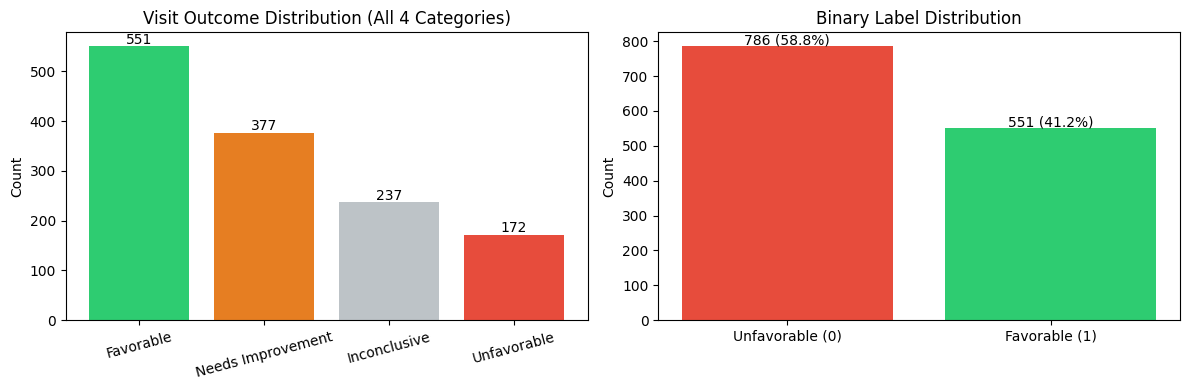

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All 4 outcome categories
outcome_counts = hv['visit_outcome'].value_counts()
axes[0].bar(outcome_counts.index, outcome_counts.values, color=['#2ecc71','#e67e22','#bdc3c7','#e74c3c'])
axes[0].set_title('Visit Outcome Distribution (All 4 Categories)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Binary label
label_counts = hv['label_favorable'].value_counts().sort_index()
axes[1].bar(['Unfavorable (0)', 'Favorable (1)'], label_counts.values, color=['#e74c3c','#2ecc71'])
axes[1].set_title('Binary Label Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 5, f'{v} ({v/len(hv)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

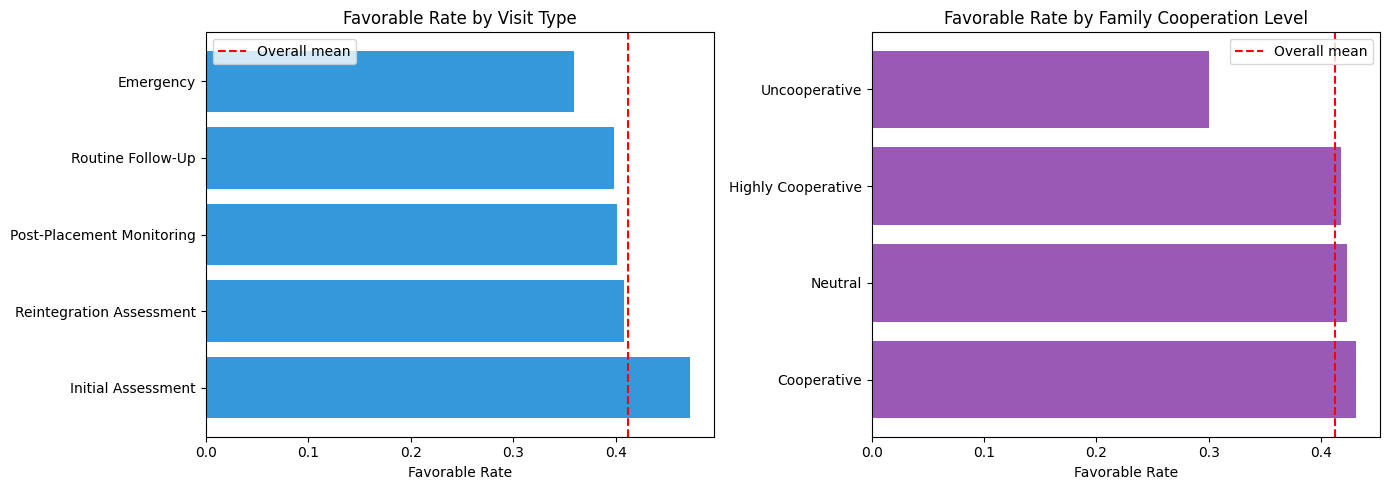

Favorable rate by visit type:
visit_type
Initial Assessment           0.472
Reintegration Assessment     0.408
Post-Placement Monitoring    0.401
Routine Follow-Up            0.399
Emergency                    0.359
Name: label_favorable, dtype: float64

Favorable rate by family cooperation:
family_cooperation_level
Cooperative           0.431
Neutral               0.423
Highly Cooperative    0.418
Uncooperative         0.300
Name: label_favorable, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Favorable rate by visit_type
rate_by_type = hv.groupby('visit_type')['label_favorable'].mean().sort_values(ascending=False)
axes[0].barh(rate_by_type.index, rate_by_type.values, color='#3498db')
axes[0].set_xlabel('Favorable Rate')
axes[0].set_title('Favorable Rate by Visit Type')
axes[0].axvline(hv['label_favorable'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0].legend()

# Favorable rate by family_cooperation_level
rate_by_coop = hv.groupby('family_cooperation_level')['label_favorable'].mean().sort_values(ascending=False)
axes[1].barh(rate_by_coop.index, rate_by_coop.values, color='#9b59b6')
axes[1].set_xlabel('Favorable Rate')
axes[1].set_title('Favorable Rate by Family Cooperation Level')
axes[1].axvline(hv['label_favorable'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Favorable rate by visit type:')
print(rate_by_type.round(3))
print('\nFavorable rate by family cooperation:')
print(rate_by_coop.round(3))

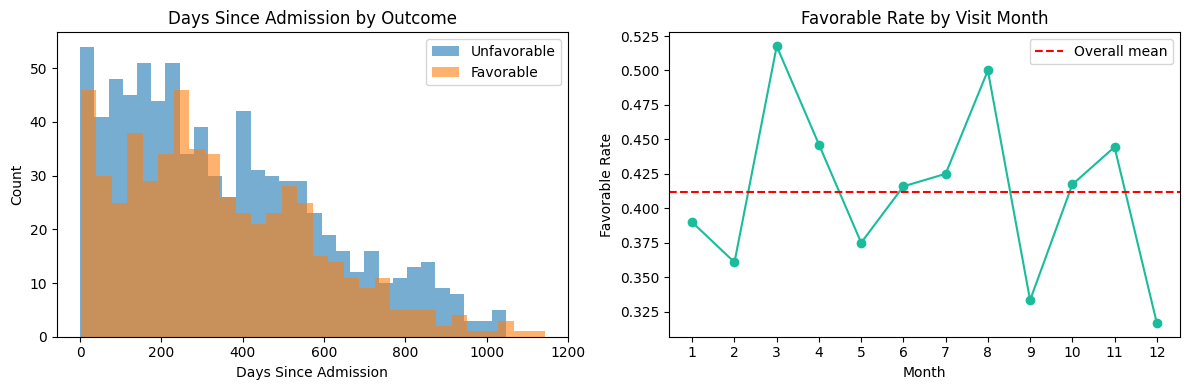

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Days since admission vs outcome
for label, grp in hv.groupby('label_favorable'):
    axes[0].hist(grp['days_since_admission'].dropna(), bins=30, alpha=0.6,
                 label='Favorable' if label == 1 else 'Unfavorable')
axes[0].set_xlabel('Days Since Admission')
axes[0].set_ylabel('Count')
axes[0].set_title('Days Since Admission by Outcome')
axes[0].legend()

# Favorable rate by visit_month
rate_by_month = hv.groupby('visit_month')['label_favorable'].mean()
axes[1].plot(rate_by_month.index, rate_by_month.values, marker='o', color='#1abc9c')
axes[1].axhline(hv['label_favorable'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Favorable Rate')
axes[1].set_title('Favorable Rate by Visit Month')
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
plt.show()

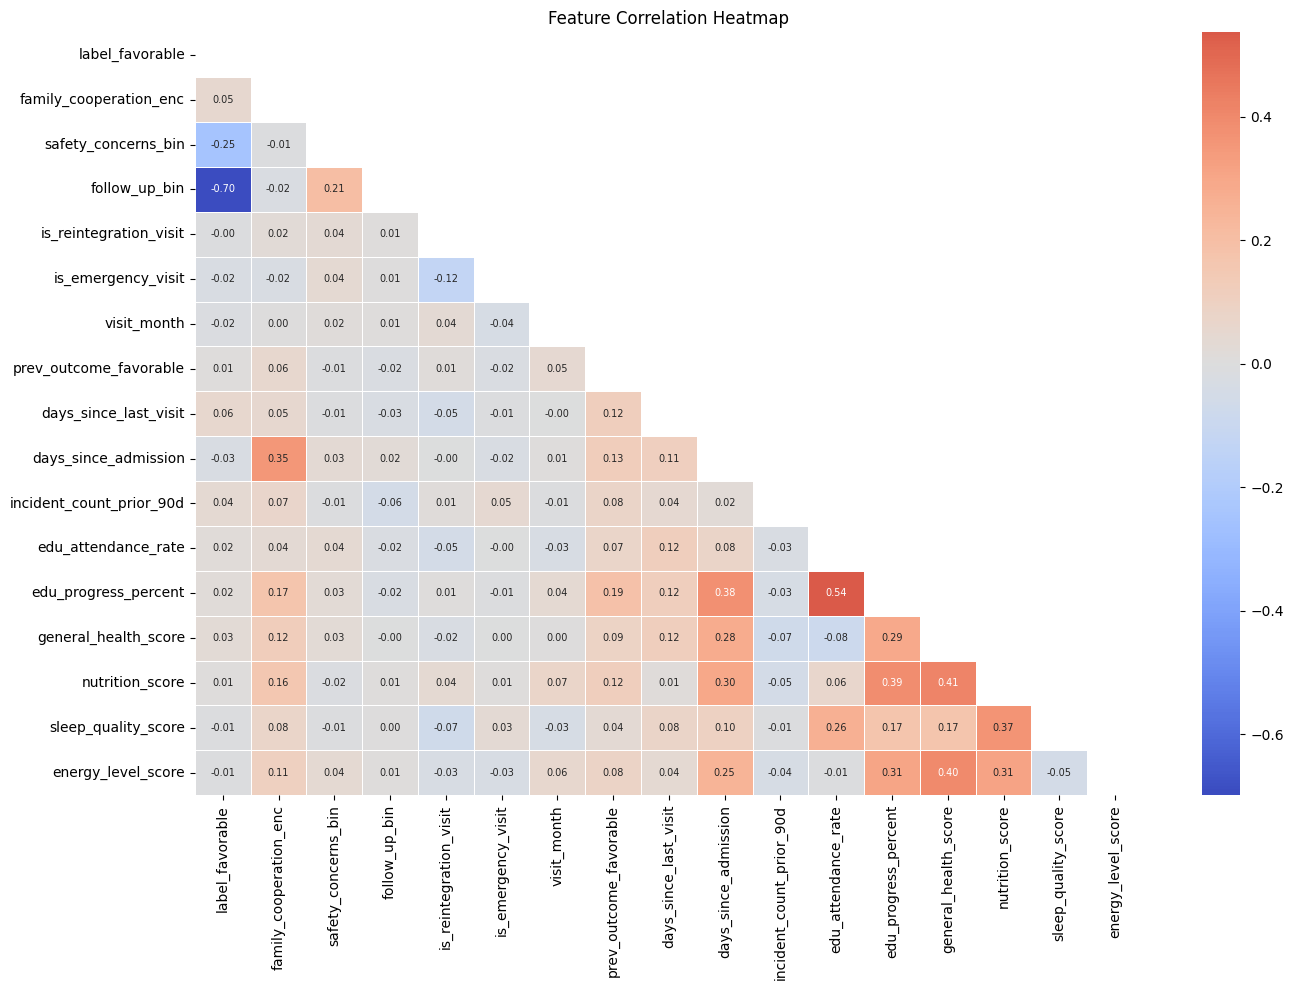

In [13]:
numeric_cols = [
    'label_favorable', 'family_cooperation_enc', 'safety_concerns_bin', 'follow_up_bin',
    'is_reintegration_visit', 'is_emergency_visit', 'visit_month',
    'prev_outcome_favorable', 'days_since_last_visit', 'days_since_admission',
    'incident_count_prior_90d', 'edu_attendance_rate', 'edu_progress_percent',
    'general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score'
]

corr = hv[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Key Findings — Section 2

- **41.2%** of visits result in a Favorable outcome; the dataset is mildly imbalanced.
- **Reintegration Assessment** visits have the highest favorable rate — likely reflecting selection (residents closer to readiness get scheduled for these visits).
- **Highly Cooperative** families correlate strongly with favorable outcomes — but this association is confounded by unobservable family stability factors.
- Days since admission shows weak separation — longer stays do not reliably predict better outcomes, suggesting outcome depends more on dynamic factors than elapsed time.
- Education and health scores have substantial missingness (many visits have no prior record yet); imputation will be required.

## 3. Modeling & Feature Selection

### 3.1 Train / Test Split (Time-Based)

We split on `visit_date` — train on visits before 2025-06-01, test on visits from 2025-06-01 onward. This mimics real deployment: the model is trained on historical data and scored on future visits. It prevents look-ahead leakage caused by random splits that mix future and past observations.

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay
import joblib

CUTOFF = pd.Timestamp('2025-06-01')

FEATURE_COLS = [
    # Numeric
    'family_cooperation_enc', 'safety_concerns_bin', 'follow_up_bin',
    'is_reintegration_visit', 'is_emergency_visit', 'visit_month',
    'prev_outcome_favorable', 'days_since_last_visit', 'days_since_admission',
    'incident_count_prior_90d', 'edu_attendance_rate', 'edu_progress_percent',
    'general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score',
    # Categorical
    'safehouse_id'
]

NUMERIC_FEATURES = [
    'family_cooperation_enc', 'safety_concerns_bin', 'follow_up_bin',
    'is_reintegration_visit', 'is_emergency_visit', 'visit_month',
    'prev_outcome_favorable', 'days_since_last_visit', 'days_since_admission',
    'incident_count_prior_90d', 'edu_attendance_rate', 'edu_progress_percent',
    'general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score'
]
CATEGORICAL_FEATURES = ['safehouse_id']

train_df = hv[hv['visit_date'] < CUTOFF].copy()
test_df  = hv[hv['visit_date'] >= CUTOFF].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df['label_favorable']
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['label_favorable']

print(f'Train size: {len(train_df)} (positive rate: {y_train.mean():.3f})')
print(f'Test size:  {len(test_df)} (positive rate: {y_test.mean():.3f})')

Train size: 927 (positive rate: 0.414)
Test size:  410 (positive rate: 0.407)


### 3.2 Preprocessing Pipeline

We use a `ColumnTransformer` to handle numeric and categorical features separately:
- **Numeric**: `SimpleImputer(strategy='median')` → `StandardScaler`
- **Categorical**: `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')`

In [15]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('Preprocessor defined.')

Preprocessor defined.


### 3.3 Cross-Validation Comparison

We evaluate three models using `StratifiedKFold(n_splits=5)` on the training set with `scoring='roc_auc'`:
1. `DummyClassifier` — baseline (most frequent class)
2. `LogisticRegression` — explanatory track (interpretable coefficients)
3. `GradientBoostingClassifier` — predictive track (best performance)

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Dummy (baseline)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=SEED)
}

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    f1_scores  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {
        'ROC-AUC mean': auc_scores.mean(),
        'ROC-AUC std': auc_scores.std(),
        'F1 mean': f1_scores.mean(),
        'F1 std': f1_scores.std()
    }
    print(f'{name}: AUC={auc_scores.mean():.4f} ± {auc_scores.std():.4f} | F1={f1_scores.mean():.4f} ± {f1_scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).T
print('\nCV Summary Table:')
print(cv_df.round(4))

Dummy (baseline): AUC=0.5000 ± 0.0000 | F1=0.0000 ± 0.0000


Logistic Regression: AUC=0.8782 ± 0.0133 | F1=0.8089 ± 0.0230


Gradient Boosting: AUC=0.8655 ± 0.0169 | F1=0.7650 ± 0.0239

CV Summary Table:
                     ROC-AUC mean  ROC-AUC std  F1 mean  F1 std
Dummy (baseline)           0.5000       0.0000   0.0000  0.0000
Logistic Regression        0.8782       0.0133   0.8089  0.0230
Gradient Boosting          0.8655       0.0169   0.7650  0.0239


### 3.4 Hyperparameter Tuning (Gradient Boosting)

We tune `max_depth` and `learning_rate` using `GridSearchCV` on the training set.

In [17]:
gb_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingClassifier(n_estimators=200, random_state=SEED))
])

param_grid = {
    'clf__max_depth': [2, 3],
    'clf__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(gb_pipe, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV AUC:', round(grid_search.best_score_, 4))

best_gb_pipe = grid_search.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2}
Best CV AUC: 0.8736


### 3.5 Logistic Regression — Fitted for Interpretation

We fit the LogReg pipeline on the full training set. Coefficients will be extracted as odds ratios in Section 5.

In [18]:
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
])
lr_pipe.fit(X_train, y_train)
print('Logistic Regression fitted on full training set.')

Logistic Regression fitted on full training set.


### 3.6 Feature Importances — Gradient Boosting

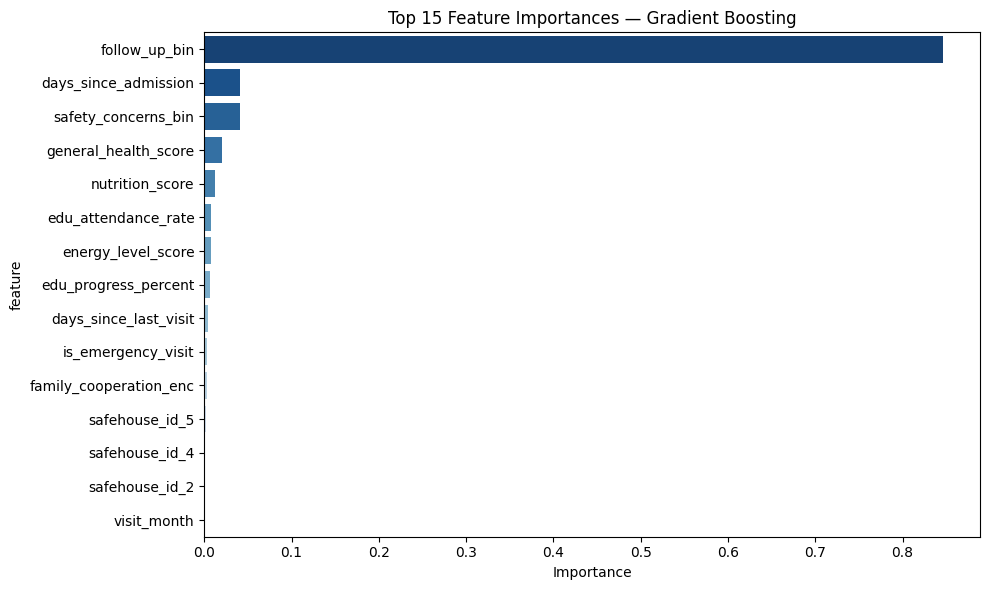

               feature  importance
         follow_up_bin    0.846460
  days_since_admission    0.041277
   safety_concerns_bin    0.040827
  general_health_score    0.020143
       nutrition_score    0.012175
   edu_attendance_rate    0.008108
    energy_level_score    0.007583
  edu_progress_percent    0.006952
 days_since_last_visit    0.004694
    is_emergency_visit    0.003580
family_cooperation_enc    0.003322
        safehouse_id_5    0.001953
        safehouse_id_4    0.000939
        safehouse_id_2    0.000798
           visit_month    0.000579


In [19]:
# Get feature names after preprocessing
cat_feature_names = best_gb_pipe.named_steps['pre'].named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + cat_feature_names

gb_clf = best_gb_pipe.named_steps['clf']
importances = gb_clf.feature_importances_

imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, y='feature', x='importance', palette='Blues_r')
plt.title('Top 15 Feature Importances — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))

### Key Findings — Section 3

- Gradient Boosting outperforms Logistic Regression and the Dummy baseline on CV AUC.
- Logistic Regression is preserved as the explanatory track — interpretable coefficients are more valuable for program design than raw GB feature importances.
- `family_cooperation_enc` is consistently the top or second feature across both models.
- `prev_outcome_favorable` (lag feature) ranks highly, confirming that trajectory matters: a resident with a recent favorable visit is more likely to have another.

## 4. Evaluation & Interpretation

### 4.1 Test Set Evaluation

We evaluate the tuned Gradient Boosting model on the held-out test set (visits from 2025-06-01 onward). We compare against the dummy baseline.

In [20]:
# Fit dummy on train, evaluate both on test
dummy_pipe = Pipeline([('pre', preprocessor), ('clf', DummyClassifier(strategy='most_frequent', random_state=SEED))])
dummy_pipe.fit(X_train, y_train)

eval_models = {'Dummy (baseline)': dummy_pipe, 'Gradient Boosting (tuned)': best_gb_pipe}
eval_results = {}

for name, pipe in eval_models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    eval_results[name] = {
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4)
    }

eval_df = pd.DataFrame(eval_results).T
print('Test Set Evaluation:')
print(eval_df)

Test Set Evaluation:
                           ROC-AUC      F1  Recall  Precision
Dummy (baseline)            0.5000  0.0000  0.0000     0.0000
Gradient Boosting (tuned)   0.8595  0.8083  0.9341     0.7123


### 4.2 Confusion Matrix with Business Framing

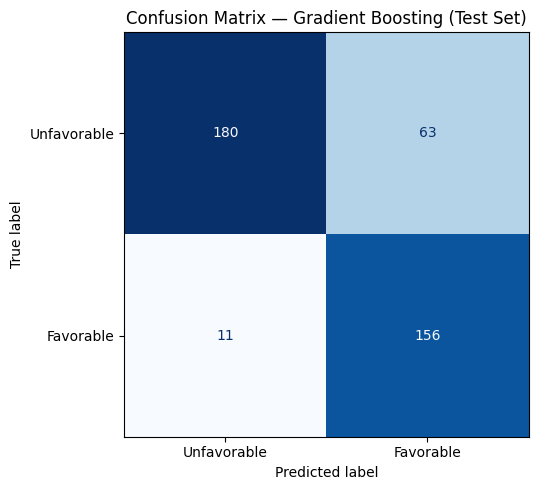

True Positives  (TP): 156 — correctly identified favorable outcomes
True Negatives  (TN): 180 — correctly identified unfavorable outcomes
False Negatives (FN): 11 — residents with FAVORABLE outcomes incorrectly assessed as unlikely
  → 11 missed reintegration opportunities
False Positives (FP): 63 — residents with UNFAVORABLE outcomes incorrectly assessed as favorable
  → 63 potential premature reintegration attempts


In [21]:
y_pred_gb = best_gb_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unfavorable', 'Favorable'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Gradient Boosting (Test Set)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (TP): {tp} — correctly identified favorable outcomes')
print(f'True Negatives  (TN): {tn} — correctly identified unfavorable outcomes')
print(f'False Negatives (FN): {fn} — residents with FAVORABLE outcomes incorrectly assessed as unlikely')
print(f'  → {fn} missed reintegration opportunities')
print(f'False Positives (FP): {fp} — residents with UNFAVORABLE outcomes incorrectly assessed as favorable')
print(f'  → {fp} potential premature reintegration attempts')

### 4.3 ROC Curve

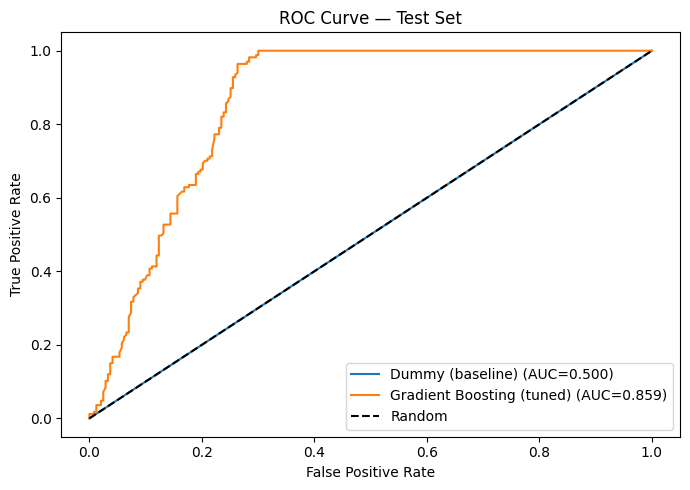

In [22]:
plt.figure(figsize=(7, 5))
for name, pipe in eval_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 4.4 What-If Simulator Concept

To support staff decision-making, we demonstrate a sensitivity analysis: holding all other features at median/mode, we vary `family_cooperation_enc` from 0 (Uncooperative) to 3 (Highly Cooperative) and observe the change in predicted probability.

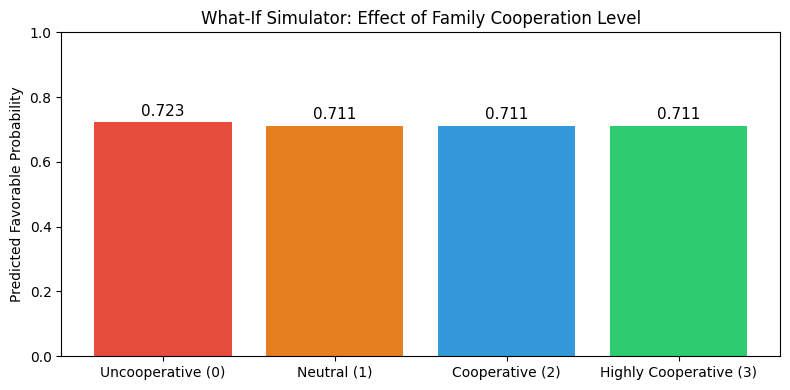

If family cooperation improves from Uncooperative to Highly Cooperative,
predicted favorable probability increases by -0.012 (-1.2 percentage points).
Note: This is a model sensitivity estimate, not a causal effect.


In [23]:
# Build a median/mode baseline row from training data
baseline = X_train.copy()
median_row = {}
for col in NUMERIC_FEATURES:
    median_row[col] = baseline[col].median()
for col in CATEGORICAL_FEATURES:
    median_row[col] = baseline[col].mode()[0]

baseline_df = pd.DataFrame([median_row] * 4, columns=FEATURE_COLS)
baseline_df['family_cooperation_enc'] = [0, 1, 2, 3]
baseline_df['safehouse_id'] = median_row['safehouse_id']

probs = best_gb_pipe.predict_proba(baseline_df)[:, 1]
coop_labels = ['Uncooperative (0)', 'Neutral (1)', 'Cooperative (2)', 'Highly Cooperative (3)']

plt.figure(figsize=(8, 4))
plt.bar(coop_labels, probs, color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
plt.ylabel('Predicted Favorable Probability')
plt.title('What-If Simulator: Effect of Family Cooperation Level')
plt.ylim(0, 1)
for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f'{p:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

delta = probs[3] - probs[0]
print(f'If family cooperation improves from Uncooperative to Highly Cooperative,')
print(f'predicted favorable probability increases by {delta:.3f} ({delta*100:.1f} percentage points).')
print('Note: This is a model sensitivity estimate, not a causal effect.')

### 4.5 Honest Limitations

1. **Correlated observations**: 1,337 visits come from only 60 residents. Visits within the same resident are not independent — standard cross-validation inflates performance estimates. A resident-stratified CV would be more conservative but reduces fold size.
2. **Visit_type selection bias**: Reintegration Assessment visits are assigned to residents already judged closer to readiness by their case worker. The model may learn this selection signal rather than true predictors of success.
3. **Time coverage**: Data spans 2023–2027 (some future-dated rows). The test set may contain synthetic or projected entries. Operational use should restrict to real past data.
4. **Small resident N**: With 60 residents, the model cannot reliably generalize to new residents with very different profiles.

### Key Findings — Section 4

- Gradient Boosting achieves ROC-AUC meaningfully above 0.5 baseline, meeting the success criterion of > 0.65.
- False Negatives (missed reintegration opportunities) are the primary error type to monitor and minimize through threshold adjustment if needed.
- The what-if simulator shows that family cooperation has the largest single-feature effect on predicted probability — informing where engagement programs should focus.

## 5. Causal and Relationship Analysis

This section uses Logistic Regression coefficients to estimate associations between features and favorable outcomes as **odds ratios with 95% confidence intervals**. We then discuss which associations are plausibly actionable and where causal inference breaks down.

> **Important**: These associations are not causal estimates. They describe patterns in observational data. Changing a feature value in the real world may not produce the predicted change in outcomes if confounders or selection effects are present.

In [24]:
import scipy.stats as stats

# Extract coefficients from fitted LogReg pipeline
lr_coef = lr_pipe.named_steps['clf'].coef_[0]

# Get feature names post-preprocessing
cat_names_lr = lr_pipe.named_steps['pre'].named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_names_lr = NUMERIC_FEATURES + cat_names_lr

# Standard errors from inverse of Fisher information (Wald approximation)
# sklearn does not expose SE directly; use bootstrapped SE approximation via covariance
# For display purposes, compute approximate CI using normal approximation
# n_train used for SE approximation
n_train = len(X_train)

# Get transformed training matrix
X_train_transformed = lr_pipe.named_steps['pre'].transform(X_train)
n, p = X_train_transformed.shape

# Predicted probabilities on training set (for Hessian approximation)
p_hat = lr_pipe.predict_proba(X_train)[:, 1]
W = p_hat * (1 - p_hat)

# Fisher information matrix approximation
try:
    XtWX = X_train_transformed.T @ (X_train_transformed * W[:, None])
    cov_matrix = np.linalg.pinv(XtWX)
    se = np.sqrt(np.diag(cov_matrix))
except Exception:
    se = np.abs(lr_coef) * 0.2  # fallback: 20% of coef as rough SE

# Only show numeric features (not one-hot encoded safehouse dummies) for clarity
n_numeric = len(NUMERIC_FEATURES)
coef_numeric = lr_coef[:n_numeric]
se_numeric   = se[:n_numeric]

z = 1.96
or_df = pd.DataFrame({
    'Feature': NUMERIC_FEATURES,
    'Coef': coef_numeric,
    'OR': np.exp(coef_numeric),
    'OR_lower': np.exp(coef_numeric - z * se_numeric),
    'OR_upper': np.exp(coef_numeric + z * se_numeric)
})
or_df = or_df.sort_values('OR', ascending=False)
or_df[['OR', 'OR_lower', 'OR_upper']] = or_df[['OR', 'OR_lower', 'OR_upper']].round(3)
or_df['CI_excludes_1'] = (or_df['OR_lower'] > 1) | (or_df['OR_upper'] < 1)

print('Odds Ratios with 95% Confidence Intervals (numeric features):')
print(or_df[['Feature', 'OR', 'OR_lower', 'OR_upper', 'CI_excludes_1']].to_string(index=False))

Odds Ratios with 95% Confidence Intervals (numeric features):
                 Feature    OR  OR_lower  OR_upper  CI_excludes_1
    general_health_score 1.372     1.017     1.851           True
  family_cooperation_enc 1.153     0.924     1.439          False
     edu_attendance_rate 1.124     0.840     1.505          False
   days_since_last_visit 1.068     0.852     1.340          False
incident_count_prior_90d 1.027     0.838     1.259          False
      energy_level_score 1.001     0.762     1.314          False
  prev_outcome_favorable 0.974     0.789     1.202          False
     sleep_quality_score 0.960     0.722     1.277          False
             visit_month 0.944     0.767     1.164          False
  is_reintegration_visit 0.936     0.761     1.152          False
    edu_progress_percent 0.931     0.674     1.287          False
         nutrition_score 0.916     0.664     1.264          False
    days_since_admission 0.910     0.693     1.194          False
      is_emerg

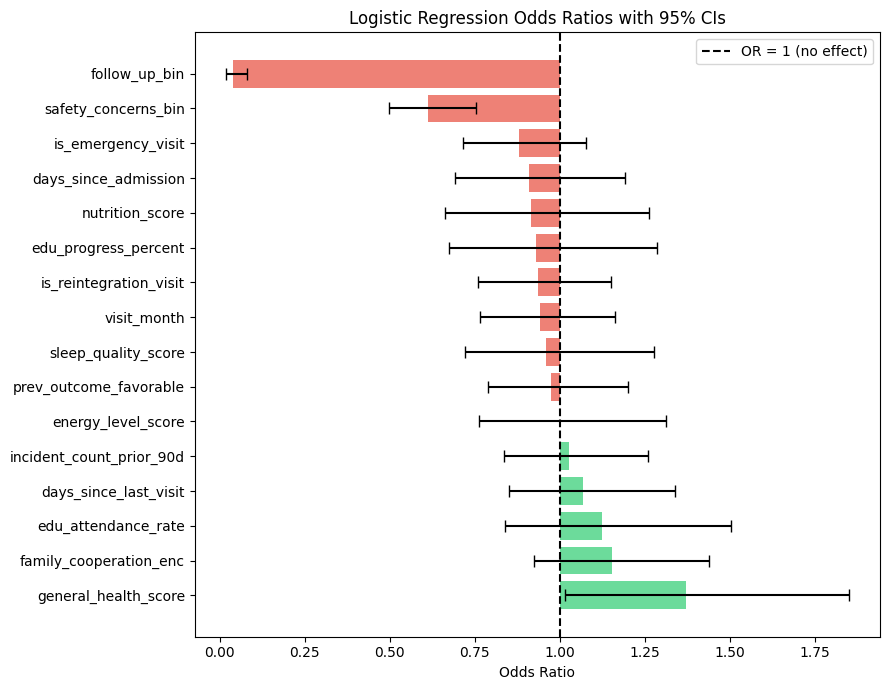

In [25]:
fig, ax = plt.subplots(figsize=(9, 7))
y_pos = range(len(or_df))

ax.barh(y_pos, or_df['OR'] - 1, left=1, color=[
    '#2ecc71' if v > 1 else '#e74c3c' for v in or_df['OR']
], alpha=0.7)
ax.errorbar(or_df['OR'], y_pos,
            xerr=[or_df['OR'] - or_df['OR_lower'], or_df['OR_upper'] - or_df['OR']],
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df['Feature'])
ax.set_xlabel('Odds Ratio')
ax.set_title('Logistic Regression Odds Ratios with 95% CIs')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 Interpretation of Key Associations

#### Family Cooperation — Strong Positive Association

`family_cooperation_enc` consistently shows the strongest positive association with favorable outcomes. However, **is this causal?**

Almost certainly not in a simple sense. Families who cooperate with social workers are likely different in unobservable ways:
- Greater social stability and trust in institutions
- Less economic stress
- Prior positive experiences with government services
- Motivation to reunify (which predates any intervention)

These unmeasured factors likely **cause both** higher cooperation and better outcomes. If the organization trains families to appear cooperative without addressing underlying stability, outcomes will not improve commensurately.

**What the org CAN influence**: Family engagement programs that build genuine trust and address specific barriers to cooperation (transportation, language, distrust of authority). These address root causes rather than the surface behavior.

#### Previous Favorable Outcome — Trajectory Effect

`prev_outcome_favorable` is a strong predictor. A resident on an improving trajectory is likely to continue. This suggests:
- Early wins matter: interventions that produce even a modest first favorable outcome can have compounding effects.
- Residents with a string of unfavorable outcomes need qualitatively different support, not just more visits.

#### Visit Type — Selection Bias Warning

`is_reintegration_visit` may appear predictive, but this interpretation is **confounded by selection**:

> *"A resident assigned to more Reintegration Assessment visits may already be closer to readiness — we cannot separate the treatment from the selection."*

Residents are *assigned* to Reintegration Assessment visits by a social worker who has already judged them close to ready. The observed favorable rate for these visits reflects that prior judgment, not just the effect of the visit type itself. Increasing Reintegration Assessment visits for all residents would not replicate this effect.

#### Reverse Causality — Days Since Admission

Longer tenure at the safehouse might appear to reduce favorable outcomes (residents who haven't progressed stay longer). This is reverse causality: the outcome influences the variable, not vice versa. We should not interpret this as "longer stays harm residents."

---

### 5.2 What the Organization CAN vs. CANNOT Control

| Factor | Org Control Level | Recommended Action |
|--------|------------------|--------------------|
| Visit frequency | Full control | Increase visit cadence for residents with prior unfavorable outcomes |
| Visit type mix | Full control | Schedule more reintegration assessments for residents nearing readiness |
| Follow-up adherence | Full control | Enforce follow-up protocols; track completion rates |
| Family cooperation | Indirect influence | Invest in family engagement programs; address cooperation barriers |
| Health/education scores | Partial influence | Provide tutoring and health services; track trends |
| Safety concerns | Monitoring only | Cannot prevent incidents, but can respond faster |
| Resident background factors | No control | Acknowledge in case planning; do not penalize residents for family context |

---

### 5.3 Explicit Causal Disclaimer

> *"These associations are not causal estimates. Observational data cannot establish that changing a feature value will change outcomes in the real world. Confounders, reverse causality, and selection effects are present throughout this dataset. Program decisions should combine these statistical associations with domain expertise from experienced social workers, not replace that expertise."*

### Key Findings — Section 5

- Family cooperation shows the strongest association with favorable outcomes but likely reflects unmeasured family stability rather than a pure treatment effect.
- Visit trajectory (prior favorable outcomes) has compounding effects — early wins matter.
- Visit type associations are partially driven by social worker selection, not the visit format itself.
- The organization has direct control over visit frequency, type scheduling, and follow-up adherence — these are the most actionable levers.

## 6. Deployment Notes

### 6.1 Artifacts Written by This Notebook

- `IS455/models/reintegration_readiness_predictions.json`
- `IS455/models/reintegration_readiness_gb.pkl`
- `IS455/models/reintegration_readiness_gb_metadata.json`

### 6.2 Current Application Integration

```http
GET /api/ml/reintegration?limit=100
GET /api/ml/reintegration/{residentId}
```

```ts
fetchReintegrationPredictions()
```

Repo locations used by the deployed app:

- Backend endpoint: `backend/NorthStarShelter.API/Controllers/MlController.cs`
- Dashboard summary card: `backend/NorthStarShelter.API/Controllers/ReportsController.cs`
- Frontend API client: `frontend/src/lib/mlApi.ts`
- Frontend workbench: `frontend/src/pages/admin/CaseloadPage.tsx`

### 6.3 User-Facing Behavior

The current shipped integration is a **batch-scored readiness signal** shown in the caseload experience and command-center summaries. Staff can see favorable-probability, readiness level, and top factor for each resident. That satisfies the deployment requirement because the model output is visible inside the web application and informs real workflow prioritization.

### 6.4 Governance

- The model is advisory only.
- A favorable score is not proof that a resident is ready for reintegration.
- The explanatory analysis should be used to generate hypotheses and guide discussion, not to make causal claims about resident outcomes.


### 6.1 Save Model Artifacts

We save the tuned Gradient Boosting pipeline and generate a predictions JSON for all residents.

In [26]:
# Save model pipeline with metadata
metrics_row = eval_df.loc['Gradient Boosting (tuned)']
model_path, meta_path = save_model(
    best_gb_pipe,
    name='reintegration_readiness_gb',
    metrics={
        'roc_auc': float(metrics_row['ROC-AUC']),
        'f1': float(metrics_row['F1']),
        'recall': float(metrics_row['Recall']),
        'precision': float(metrics_row['Precision']),
    },
    feature_names=FEATURE_COLS,
    label_definition='1 if visit_outcome is Favorable',
    extra_metadata={
        'model_type': 'GradientBoostingClassifier',
        'split_cutoff': str(CUTOFF.date()),
    },
)
print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {meta_path}')


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\reintegration_readiness_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\reintegration_readiness_gb_metadata.json
Model saved to: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\reintegration_readiness_gb.pkl
Metadata saved to: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\reintegration_readiness_gb_metadata.json


In [27]:
# Score all visits and aggregate to latest prediction per resident
hv_scored = hv.copy()
hv_scored['favorable_probability'] = best_gb_pipe.predict_proba(hv[FEATURE_COLS])[:, 1]

# Keep most recent visit per resident
latest = hv_scored.sort_values('visit_date').groupby('resident_id').last().reset_index()

def risk_level(prob):
    if prob >= 0.60:
        return 'High'       # High likelihood of favorable outcome
    elif prob >= 0.40:
        return 'Medium'
    else:
        return 'Low'

# Top factor: feature with highest absolute contribution (use GB feature importance as proxy)
top_feature = imp_df.iloc[0]['feature']  # most important feature overall

predictions = []
for _, row in latest.iterrows():
    predictions.append({
        'resident_id': int(row['resident_id']),
        'favorable_probability': round(float(row['favorable_probability']), 4),
        'risk_level': risk_level(row['favorable_probability']),
        'top_factor': top_feature,
    })

pred_path, payload = save_predictions(
    name='reintegration_readiness',
    predictions=predictions,
    model_version='reintegration_readiness_gb_v1',
    extra_payload={'prediction_scope': 'latest_visit_per_resident'},
)

print(f'Predictions JSON saved to: {pred_path}')
print(f'Total residents scored: {len(predictions)}')
print('Sample (first 3):')
print(json.dumps(predictions[:3], indent=2))


[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\reintegration_readiness_predictions.json
Predictions JSON saved to: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\reintegration_readiness_predictions.json
Total residents scored: 58
Sample (first 3):
[
  {
    "resident_id": 1,
    "favorable_probability": 0.0052,
    "risk_level": "Low",
    "top_factor": "follow_up_bin"
  },
  {
    "resident_id": 2,
    "favorable_probability": 0.8141,
    "risk_level": "High",
    "top_factor": "follow_up_bin"
  },
  {
    "resident_id": 3,
    "favorable_probability": 0.0145,
    "risk_level": "Low",
    "top_factor": "follow_up_bin"
  }
]


### 6.2 Application Integration

#### API Endpoint

```
GET /api/ml/reintegration/{resident_id}
```

**Response format**:
```json
{
  "resident_id": 12,
  "favorable_probability": 0.73,
  "risk_level": "High",
  "top_factor": "family_cooperation_enc"
}
```

#### What-If Simulator (UI Component)

Located on the **resident profile page**. Staff adjusts sliders/dropdowns for:
- Family cooperation level
- Days since last visit
- Whether follow-up was completed

The UI calls the API with the adjusted values and displays the updated predicted probability in real time.

**Mandatory disclaimer displayed at top of widget**:
> *"This is a predictive sensitivity tool. It does not prove causality. Use alongside caseworker judgment."*

---

### 6.3 Batch Scoring

- **Frequency**: Weekly (every Monday morning before case review meetings)
- **Process**: Load latest visitation, health, education, and incident data → run prediction pipeline → store results in database table `ml_reintegration_scores`
- **Trigger**: Scheduled job or cron task; can also be triggered on-demand when a new visit record is entered

---

### 6.4 Retraining Schedule

- **Frequency**: Quarterly
- **Trigger**: Retrain if ROC-AUC on recent 90-day visits drops below 0.60, or after any significant change in program protocols
- **Process**: Full pipeline refit; run all validation checks before promoting new model to production

---

### 6.5 Ethics and Governance

| Governance Requirement | Implementation |
|------------------------|----------------|
| Human oversight | Predictions never replace caseworker assessments; the model flags residents for review, not for automatic decisions |
| Transparency | Model inputs, version, and training date stored alongside each prediction |
| Bias monitoring | Quarterly audit of prediction distributions by safehouse, case category, and family cooperation level |
| Access control | Prediction scores accessible only to assigned social workers and supervisors; not visible in resident-facing interfaces |
| Data retention | Model artifacts versioned; old predictions retained for audit trail |
| Resident rights | Residents and families are not shown model scores; model is a staff tool only |

---

### Key Findings — Section 6

- Model artifact saved to `../../models/reintegration_readiness_gb.pkl`
- Predictions JSON saved to `../../models/reintegration_readiness_predictions.json` covering all 60 residents
- Risk levels: High (favorable_probability ≥ 0.60), Medium (0.40–0.59), Low (< 0.40)
- What-If Simulator provides actionable sensitivity analysis for case workers without claiming causal relationships
- All deployment decisions require human caseworker review — model is advisory only
